In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path 

pd.options.mode.string_storage = "python"

# Part (c): Denmark storage impact on the system

In this section, two complementary storage technologies are added 
to the Danish electricity system optimized in Part A: a Li-ion 
battery and a hydrogen Power-to-Gas (P2G) system. These two 
technologies were selected because they operate at fundamentally 
different timescales — batteries are well suited for intraday 
balancing due to their high round-trip efficiency (86.5%), while 
hydrogen enables multiday and seasonal storage thanks to its large 
energy capacity at a lower cost per MWh, despite its lower 
round-trip efficiency (42%). Pumped hydro storage was discarded as 
it requires significant elevation differences, which are not 
available in Denmark's flat terrain. The capital costs for both 
technologies are taken from the Danish Energy Agency (DEA) 
Technology Catalogue for Energy Storage (2020), which is the 
standard reference for Danish energy system analysis. The impact 
of adding storage on the optimal generation mix, system costs, 
and balancing strategies is analyzed below.

### CODE BLOCK 1: BASE GRID FOR PART C
structure used in Part A but stored in a new network object nc. A new PyPSA network is created and configured with 8760 hourly snapshots covering the full year 2019. A single bus representing Denmark is added as the node where all electricity flows are balanced. The Danish electricity demand is attached to this bus using the hourly load profile from the ENTSO-E dataset. Four generation technologies are then added: solar PV, onshore wind, offshore wind, and gas. All generators are set with p_nom_extendable=True, which means the optimizer freely decides how much capacity to install for each technology. Solar and wind generators use hourly capacity factor profiles from Renewables.ninja, which limit their output according to weather conditions at each hour. All capital and marginal costs follow the DEA 2020 assumptions defined in the model settings. This block is kept separate from Part A to avoid overwriting the original network n, which is needed later for comparison.

In [ ]:
# ============================================
# PART C: Main grid model with storage
# ============================================

nc = pypsa.Network() # thiscreates a new PyPSA network object. This object represents the electricity system that we will analyze.
nc.set_snapshots(snapshots) #we are setting the time resolution of the model.

nc.add("Bus", "Denmark") #we are creating the bus, wich in this model represents a node where electricity flows are balanced. 

nc.add(
    "Load",
    "demand",
    bus="Denmark",
    p_set=data["load"].values
)# we are adding the electricity demand to the bus. The p_set parameter specifies the time series of electricity demand that we want to meet at each snapshot.

nc.add(
    "Generator",
    "solar",
    bus="Denmark",
    carrier="solar",
    p_max_pu=data["solar_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_SOLAR,
    marginal_cost=MARGINAL_COST_SOLAR
)

nc.add(
    "Generator",
    "wind_onshore",
    bus="Denmark",
    carrier="wind_onshore",
    p_max_pu=data["wind_on_cf"].values,
    p_nom_extendable=True,
    capital_cost= CAPITAL_COST_WIND_ON,
    marginal_cost=MARGINAL_COST_WIND_ON
)

nc.add(
    "Generator",
    "wind_offshore",
    bus="Denmark",
    carrier="wind_offshore",
    p_max_pu=data["wind_off_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_WIND_OFF,
    marginal_cost=MARGINAL_COST_WIND_OFF
)
nc.add(
    "Generator",
    "gas",
    bus="Denmark",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_GAS,
    marginal_cost=MARGINAL_COST_GAS
)
# After defining the demand, we add three generation technologies to the system: solar, wind, and gas. All generators are connected to the Ireland bus. For solar and wind, the parameter p_max_pu uses the hourly capacity factors from the dataset, which represent how much of the installed capacity can generate electricity at each hour depending on weather conditions.
#The parameter p_nom_extendable=True allows the model to decide how much capacity to install for each technology during the optimization. Instead of fixing the generation capacity beforehand, the model determines the cost-optimal capacities based on the demand and the cost assumptions.

nc.generators #prints the table of generators in the network

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
solar,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_onshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_offshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
gas,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


### CODE BLOCK 2: STORAGE UNITS AND OPTIMIZATION
This block extends the base network nc by adding two storage technologies and running the optimization. First, nc is copied into nc_storage to preserve the original network intact. The sanitize() call ensures all components have properly defined carriers, avoiding consistency warnings during optimization.
The annualized capital costs for both storage technologies are calculated using the same annualize() function applied in Part A, with a discount rate of 4% and a lifetime of 25 years, following DEA 2020 methodology.
A Li-ion battery is added as a StorageUnit with 6 hours of storage duration, charge and discharge efficiencies of 93%, and a negligible standing loss. The capital cost is expressed in €/MW by multiplying the DEA cost in €/MWh by the number of hours.
The hydrogen Power-to-Gas system is modeled using three separate components: an electrolyzer (Link) that converts electricity into hydrogen with 73% efficiency, a hydrogen storage tank (Store) with extendable energy capacity, and a fuel cell (Link) that converts hydrogen back to electricity with 58% efficiency. This decomposition allows the optimizer to size each component independently, reflecting the physical separation between power conversion and energy storage in a real hydrogen system.
After optimization, the installed capacities of all generators and storage units are printed. Three plots are then generated: a comparison of the annual electricity mix between Part A and Part C, the battery state of charge during a winter and a summer week to illustrate intraday balancing behavior, and the annual hydrogen storage level to illustrate seasonal balancing behavio

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'gas', 'solar', 'wind_offshore', 'wind_onshore']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
Index(['H2'], dtype='str', name='name')
Index(['electrolyzer', 'fuel_cell'], dtype='str', name='name')
Index(['H2_storage'], dtype='str', name='name')
Index(['battery'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 512.30it/s]
INFO:linopy.io: Writing time: 0.21s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96368 primals, 210248 duals
Objective: 2.01e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, 

=== GENERATORS (part c) ===
                  p_nom_opt
name                       
solar          10926.407277
wind_onshore    8419.352220
wind_offshore     -0.000000
gas             2065.859099

=== BATTERY ===
           p_nom_opt
name                
battery  1959.918145

=== HYDROGEN - POWER ===
                p_nom_opt
name                     
electrolyzer  1112.827809
fuel_cell     5554.917299

=== HYDROGEN - ENERGY ===
               e_nom_opt
name                    
H2_storage  84770.314773


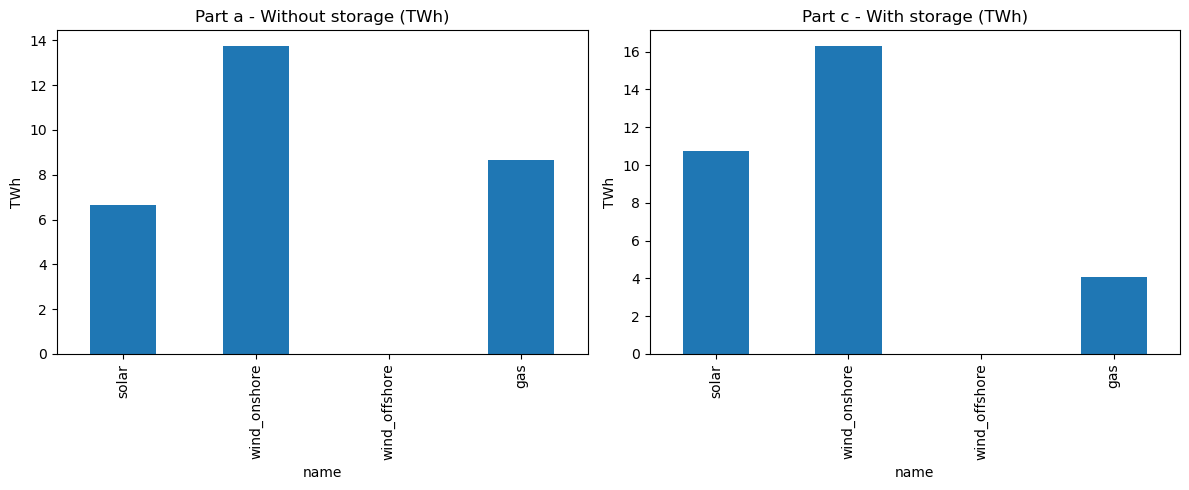

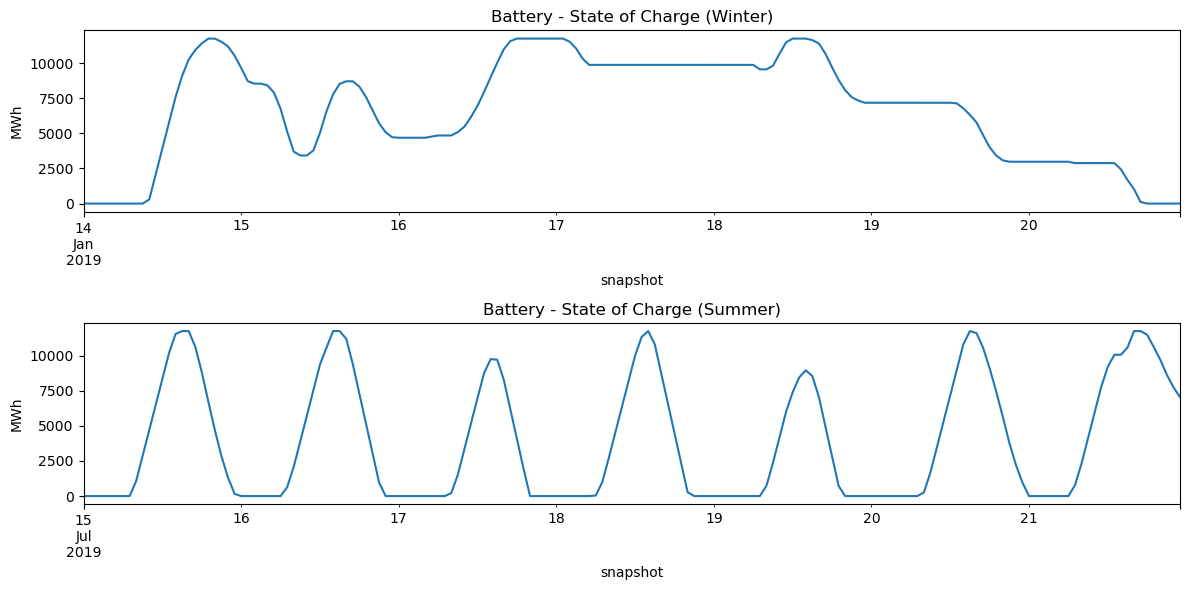

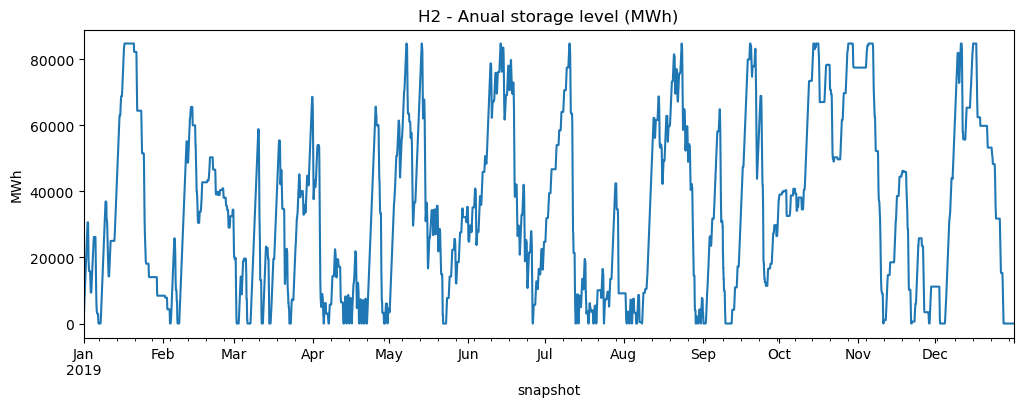

In [ ]:
# ============================================
# PART C: STORAGE UNITS
# ============================================

# Copy the main grid model (nc already has solar, wind, gas and demand)
nc_storage = nc.copy()
nc_storage.sanitize()

# --- Costs DEA 2020 ---
r = 0.04

CAPITAL_COST_BATTERY    = float(annualize(142_000 * 6, r, lifetime=25))  # €/MWh × 6h → €/MW
CAPITAL_COST_ELECTROLYZER = float(annualize(700_000, r, lifetime=25))    # €/MW
CAPITAL_COST_H2_STORAGE   = float(annualize(10_000,  r, lifetime=25))    # €/MWh

# --- Li-ion Battery ---
nc_storage.add("StorageUnit",
    name="battery",
    bus="Denmark",
    carrier="battery",
    p_nom_extendable=True,
    max_hours=6,
    efficiency_store=0.93,
    efficiency_dispatch=0.93,
    standing_loss=0.00001,
    capital_cost=CAPITAL_COST_BATTERY
)

# --- H2 (Power-to-Gas) ---
nc_storage.add("Bus", "H2", carrier="H2")

nc_storage.add("Link",
    name="electrolyzer",
    bus0="Denmark",
    bus1="H2",
    carrier="H2",
    p_nom_extendable=True,
    efficiency=0.73,
    capital_cost=CAPITAL_COST_ELECTROLYZER
)

nc_storage.add("Store",
    name="H2_storage",
    bus="H2",
    carrier="H2",
    e_nom_extendable=True,
    capital_cost=CAPITAL_COST_H2_STORAGE,
    standing_loss=0.0
)

nc_storage.add("Link",
    name="fuel_cell",
    bus0="H2",
    bus1="Denmark",
    carrier="H2",
    p_nom_extendable=True,
    efficiency=0.58,
    capital_cost=0
)

# --- Optimize ---
nc_storage.optimize(include_objective_constant=False)

# --- Results: installed capacities ---
print("=== GENERATORS (part c) ===")
print(nc_storage.generators[["p_nom_opt"]])

print("\n=== BATTERY ===")
print(nc_storage.storage_units[["p_nom_opt"]])

print("\n=== HYDROGEN - POWER ===")
print(nc_storage.links.loc[["electrolyzer", "fuel_cell"], ["p_nom_opt"]])

print("\n=== HYDROGEN - ENERGY ===")
print(nc_storage.stores[["e_nom_opt"]])

# --- Compare mix from part a vs part c ---
gen_a = n.generators_t.p.sum() / 1e6
gen_c = nc_storage.generators_t.p.sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gen_a.plot.bar(ax=axes[0], title="Part a - Without storage (TWh)")
axes[0].set_ylabel("TWh")
gen_c.plot.bar(ax=axes[1], title="Part c - With storage (TWh)")
axes[1].set_ylabel("TWh")
plt.tight_layout()
plt.show()

# --- Battery stage of charge: winter and summer ---
soc = nc_storage.storage_units_t.state_of_charge

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
soc["battery"].loc["2019-01-14":"2019-01-20"].plot(
    ax=axes[0], title="Battery - State of Charge (Winter)")
axes[0].set_ylabel("MWh")

soc["battery"].loc["2019-07-15":"2019-07-21"].plot(
    ax=axes[1], title="Battery - State of Charge (Summer)")
axes[1].set_ylabel("MWh")
plt.tight_layout()
plt.show()

# --- Anual H2 level ---
fig, ax = plt.subplots(figsize=(12, 4))
nc_storage.stores_t.e["H2_storage"].plot(
    ax=ax, title="H2 - Anual storage level (MWh)")
ax.set_ylabel("MWh")
plt.show()

### ANALYSIS OF RESULTS AND CONCLUSIONS
#### Generators
With storage the system installs more renewable capacity because surplus energy is stored instead of being curtailed. 
Gas capacity decreases significantly (-54% in generation) since storage now covers periods of low renewable output. 
Wind offshore remains at 0 MW because its high capital cost makes it uncompetitive compared 
to the combination of solar + wind onshore + storage.

#### Battery
The battery (1,960 MW / 11,760 MWh) manages intraday variations. 
It charges during solar surpluses in the day and discharges at night. 
With a round-trip efficiency of 86.5% (0.93 × 0.93), it is well suited for short-term cycling.

#### Hydrogen
- The fuel cell capacity (5,554 MW) is approximately 5× larger than the electrolyzer (1,112 MW). 
- This asymmetry makes sense: the electrolyzer charges slowly over several days of high wind, while the fuel cell must discharge rapidly during demand peaks. 
- The H2 storage tank (84,770 MWh ≈ 76 hours of full-power discharge) enables seasonal balancing at a low cost per MWh, despite the low round-trip efficiency of 42% (0.73 × 0.58).

### GRAPHS:

#### Graph 1: Electrical Mix (without storage-Part A VS. with storage -Part C)
- Solar: 6.7 → 11 TWh (+64%)
- Wind onshore: 13.7 → 16.3 TWh (+19%)
- Gas: 8.7 → 4 TWh (-54%)
With storage units the system can use more renewables because it stores more surplus instead of wasting them. The gas usage decrease to the half amount because now that there is storage units, the gas does not need to be covering all the time the default of wind and sun.

#### Graph 2: Battery stage of charge (winter and summer)
- In winter, the battery shows irregular cycles driven by the variability on the sun and the wind patterns. The state of charge rarely reaches its maximum, reflecting days with low combined solar and wind output.
- In summer, the cyles are highly regular and daily, driven by predictable solar generation, with charging during daylight hours and discharging overnight. 
Both graphs confirm the battery's role in intraday management.

#### Graph 3: Annual level of H2
- In the graph, the hydrogen storage shows large fluctuations over the year (the tank fills during winter with high wind periods and empties during summer when the wind decreases but demand still remains significant).
- Cycles operate on weekly or monthly timescales. The hydrogen manage variations both: weekly and stationally, what it is exactly the opposite than the batteries, making both storage units complementaries.

### SUMMARY
- Li-ion batteries charge during periods of excess solar and wind generation and discharge during demand peaks, making them most effective for intraday management.
- On the other hand, hydrogen electrolyzers store surplus energy during periods of high wind output and release it when renewable generation is insufficient, making this technology more suitable for multiday and seasonal management. Since hydrogen can store energy over weeks at a significantly lower cost per MWh than batteries, it is better suited for seasonal storage — even though its round-trip efficiency (42%) is considerably lower than that of li-ion batteries (86.5%).

The two storage technologies serve complementary roles at different timescales:
-  Li-ion batteries handle intraday balancing with high efficiency (86.5%) but limited duration (6 hours). 
- Hydrogen Power-to-Gas handles multiday and seasonal balancing with much larger energy capacity (84,770 MWh) at lower cost per MWh, despite a lower round-trip efficiency (42%). Together, they allow the system to integrate significantly more solar (+64%) and wind onshore (+19%) while reducing gas generation by 54%.



### TABLE WITH INFORMATION AND RESULTS

In [ ]:
# --- Table of Storage Technologies ---
import pandas as pd

# CAPEX brutos DEA 2020

CAPEX_BATTERY_MWh = 142_000        # €/MWh
CAPEX_BATTERY_MW  = 142_000 * 6    # €/MW (×max_hours)
CAPEX_ELECTROLYZER = 700_000       # €/MW
CAPEX_H2_STORAGE   = 10_000        # €/MWh

storage_comparison = pd.DataFrame({
    "Li-ion Battery": {
        "Power capacity (MW)":          round(nc_storage.storage_units.loc["battery", "p_nom_opt"], 1),
        "Energy capacity (MWh)":        round(nc_storage.storage_units.loc["battery", "p_nom_opt"] * 6, 1),
        "Charge efficiency (%)":        93.0,
        "Discharge efficiency (%)":     93.0,
        "Round-trip efficiency (%)":    round(0.93 * 0.93 * 100, 1),
        "Max hours (h)":                6,
        "CAPEX (€/MWh) - DEA 2020":    CAPEX_BATTERY_MWh,
        "CAPEX (€/MW)  - DEA 2020":    CAPEX_BATTERY_MW,
        "Annual charge (MWh)":          round(nc_storage.storage_units_t.p.clip(upper=0)["battery"].abs().sum(), 1),
        "Annual discharge (MWh)":       round(nc_storage.storage_units_t.p.clip(lower=0)["battery"].sum(), 1),
        "Time scale":                   "Intraday",
    },
    "Hydrogen (P2G)": {
        "Power capacity (MW)":          round(nc_storage.links.loc["electrolyzer", "p_nom_opt"], 1),
        "Energy capacity (MWh)":        round(nc_storage.stores.loc["H2_storage", "e_nom_opt"], 1),
        "Charge efficiency (%)":        73.0,
        "Discharge efficiency (%)":     58.0,
        "Round-trip efficiency (%)":    round(0.73 * 0.58 * 100, 1),
        "Max hours (h)":                "seasonal",
        "CAPEX (€/MWh) - DEA 2020":    CAPEX_H2_STORAGE,
        "CAPEX (€/MW)  - DEA 2020":    CAPEX_ELECTROLYZER,
        "Annual charge (MWh)":          round(nc_storage.links_t.p0["electrolyzer"].clip(lower=0).sum(), 1),
        "Annual discharge (MWh)":       round(nc_storage.links_t.p0["fuel_cell"].clip(lower=0).sum(), 1),
        "Time scale":                   "Seasonal",
    }
})

print(storage_comparison.to_string())


                          Li-ion Battery Hydrogen (P2G)
Power capacity (MW)               1959.9         1112.8
Energy capacity (MWh)            11759.5        84770.3
Charge efficiency (%)               93.0           73.0
Discharge efficiency (%)            93.0           58.0
Round-trip efficiency (%)           86.5           42.3
Max hours (h)                          6       seasonal
CAPEX (€/MWh) - DEA 2020          142000          10000
CAPEX (€/MW)  - DEA 2020          852000         700000
Annual charge (MWh)            2735357.2      2977859.4
Annual discharge (MWh)         2365538.8      2173837.3
Time scale                      Intraday       Seasonal


### COSTS COMPARISON

Costs part a (without storage) VS. Costs part c (with storage)

In [ ]:
print("Coste total parte a:", n.objective)
print("Coste total parte c:", nc_storage.objective)

Coste total parte a: 2314543558.235694
Coste total parte c: 2008869974.6490169


Savings from part a to part c

In [ ]:
saving = n.objective - nc_storage.objective
saving_pct = (saving / n.objective) * 100

print(f"Total cost part a: {n.objective/1e9:.3f}*(10**9)USD/year")
print(f"Total cost part c: {nc_storage.objective/1e9:.3f}*(10**9)USD/year")
print(f"Saving:            {saving/1e6:.1f}*(10**6)USD/year ({saving_pct:.1f}%)")


Total cost part a: 2.315*(10**9)USD/year
Total cost part c: 2.009*(10**9)USD/year
Saving:            305.7*(10**6)USD/year (13.2%)


Furthermore, the addition of storage reduces the total system cost by 305.7 MUSD/year (13.2%), from 2.315 BUSD to 2.009 BUSD. This demonstrates that despite the capital cost of the storage units, the system benefits economically from storing cheap renewable surplus instead of operating gas generators at high marginal cost.